In [97]:
# basic libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# data manipulation libraries
from scipy import stats
from scipy.stats import f_oneway
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# clustering libraries
from sklearn.cluster import KMeans, DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, adjusted_rand_score

# set plot style 
sns.set_palette("viridis")

# Data Description and Exploration
 
First, loading the dataset and exploring its basic structure and characteristics.

In [98]:
# Load the dataset
df = pd.read_csv('Meteorite_Landings_20250402.csv')

In [99]:
# Basic dataset exploration
print("Dataset shape:", df.shape)

Dataset shape: (45716, 10)


In [100]:
print("First 5 rows:")
print(df.head())

First 5 rows:
       name   id nametype     recclass  mass (g)  fall    year    reclat  \
0    Aachen    1    Valid           L5      21.0  Fell  1880.0  50.77500   
1    Aarhus    2    Valid           H6     720.0  Fell  1951.0  56.18333   
2      Abee    6    Valid          EH4  107000.0  Fell  1952.0  54.21667   
3  Acapulco   10    Valid  Acapulcoite    1914.0  Fell  1976.0  16.88333   
4   Achiras  370    Valid           L6     780.0  Fell  1902.0 -33.16667   

     reclong           GeoLocation  
0    6.08333     (50.775, 6.08333)  
1   10.23333  (56.18333, 10.23333)  
2 -113.00000    (54.21667, -113.0)  
3  -99.90000     (16.88333, -99.9)  
4  -64.95000   (-33.16667, -64.95)  


In [101]:
print("Last 5 rows:")
print(df.tail())

Last 5 rows:
             name     id nametype              recclass  mass (g)   fall  \
45711  Zillah 002  31356    Valid               Eucrite     172.0  Found   
45712      Zinder  30409    Valid  Pallasite, ungrouped      46.0  Found   
45713        Zlin  30410    Valid                    H4       3.3  Found   
45714   Zubkovsky  31357    Valid                    L6    2167.0  Found   
45715  Zulu Queen  30414    Valid                  L3.7     200.0  Found   

         year    reclat    reclong             GeoLocation  
45711  1990.0  29.03700   17.01850       (29.037, 17.0185)  
45712  1999.0  13.78333    8.96667     (13.78333, 8.96667)  
45713  1939.0  49.25000   17.66667       (49.25, 17.66667)  
45714  2003.0  49.78917   41.50460     (49.78917, 41.5046)  
45715  1976.0  33.98333 -115.68333  (33.98333, -115.68333)  


In [102]:
print("Missing values per column:")
print(df.isnull().sum())

Missing values per column:
name              0
id                0
nametype          0
recclass          0
mass (g)        131
fall              0
year            291
reclat         7315
reclong        7315
GeoLocation    7315
dtype: int64


In [103]:
print("Basic statistics:")
print(df.describe())

Basic statistics:
                 id      mass (g)          year        reclat       reclong
count  45716.000000  4.558500e+04  45425.000000  38401.000000  38401.000000
mean   26889.735104  1.327808e+04   1991.828817    -39.122580     61.074319
std    16860.683030  5.749889e+05     25.052766     46.378511     80.647298
min        1.000000  0.000000e+00    860.000000    -87.366670   -165.433330
25%    12688.750000  7.200000e+00   1987.000000    -76.714240      0.000000
50%    24261.500000  3.260000e+01   1998.000000    -71.500000     35.666670
75%    40656.750000  2.026000e+02   2003.000000      0.000000    157.166670
max    57458.000000  6.000000e+07   2101.000000     81.166670    354.473330


Additional preliminary exploration


In [104]:
print("Column datatypes:")
print(df.dtypes)

Column datatypes:
name            object
id               int64
nametype        object
recclass        object
mass (g)       float64
fall            object
year           float64
reclat         float64
reclong        float64
GeoLocation     object
dtype: object


In [105]:
print("Unique values in categorical columns:")
for col in ['recclass', 'fall', 'nametype']:
    print(f"\n{col} unique values ({df[col].nunique()}):")
    print(df[col].value_counts().head(10))

Unique values in categorical columns:

recclass unique values (466):
recclass
L6      8285
H5      7142
L5      4796
H6      4528
H4      4211
LL5     2766
LL6     2043
L4      1253
H4/5     428
CM2      416
Name: count, dtype: int64

fall unique values (2):
fall
Found    44609
Fell      1107
Name: count, dtype: int64

nametype unique values (2):
nametype
Valid     45641
Relict       75
Name: count, dtype: int64


In [106]:
print("Temporal range:")
print(f"Earliest record: {df['year'].min()}, Latest record: {df['year'].max()}")

Temporal range:
Earliest record: 860.0, Latest record: 2101.0


In [107]:
print("Geographical coverage:")
print(f"Latitude range: {df['reclat'].min()} to {df['reclat'].max()}")
print(f"Longitude range: {df['reclong'].min()} to {df['reclong'].max()}")

Geographical coverage:
Latitude range: -87.36667 to 81.16667
Longitude range: -165.43333 to 354.47333


# Data Preprocessing
 
This section handles data cleaning, anomaly detection, and missing value imputation.

In [108]:
# handling the year anomalies
print("Year range before cleaning:")
print(f"Min year: {df['year'].min()}, Max year: {df['year'].max()}")

Year range before cleaning:
Min year: 860.0, Max year: 2101.0


In [109]:
# display and fix future years (beyond 2025)
future_years = df[df['year'] > 2025]
print(f"Number of records with future years (>2025): {len(future_years)}")


Number of records with future years (>2025): 1


In [110]:
# fix anomalous years
if len(future_years) > 0:
    print("Distribution of future years:")
    print(future_years['year'].value_counts().sort_index())
df.loc[df['year'] > 2025, 'year'] = np.nan

Distribution of future years:
year
2101.0    1
Name: count, dtype: int64


In [111]:
# handling zero mass records
zero_mass = df[df['mass (g)'] == 0]
print(f"\nNumber of records with zero mass: {len(zero_mass)}")


Number of records with zero mass: 19


In [112]:
# handle zero mass records for log transformations

if len(zero_mass) > 0:
    print("Sample of zero-mass records:")
    print(zero_mass.head(5))
    print("\nZero-mass records by class:")
    print(zero_mass['recclass'].value_counts().head())
    print("\nZero-mass records by fall type:")
    print(zero_mass['fall'].value_counts())
    
df.loc[df['mass (g)'] == 0, 'mass (g)'] = 0.01

Sample of zero-mass records:
                      name     id nametype     recclass  mass (g)   fall  \
12640                 Gove  52859   Relict  Relict iron       0.0  Found   
25557  Miller Range 090478  55953    Valid          CO3       0.0  Found   
31061       Österplana 048  56147   Relict    Relict OC       0.0  Found   
31062       Österplana 049  56148   Relict    Relict OC       0.0  Found   
31063       Österplana 050  56149   Relict    Relict OC       0.0  Found   

         year    reclat    reclong             GeoLocation  
12640  1979.0 -12.26333  136.83833  (-12.26333, 136.83833)  
25557  2009.0   0.00000    0.00000              (0.0, 0.0)  
31061  2004.0  58.58333   13.43333    (58.58333, 13.43333)  
31062  2012.0  58.58333   13.43333    (58.58333, 13.43333)  
31063  2003.0  58.58333   13.43333    (58.58333, 13.43333)  

Zero-mass records by class:
recclass
Relict OC      17
Relict iron     1
CO3             1
Name: count, dtype: int64

Zero-mass records by fall typ

In [113]:
# fix longitude values outside -180 to 180 range
df.loc[df['reclong'] > 180, 'reclong'] = df.loc[df['reclong'] > 180, 'reclong'] - 360

In [114]:
# examine outliers
print("\nTop 10 largest meteorites:")
top_mass = df.nlargest(10, 'mass (g)')
print(top_mass[['name', 'recclass', 'mass (g)', 'fall', 'year']])


Top 10 largest meteorites:
                  name         recclass    mass (g)   fall    year
16392             Hoba        Iron, IVB  60000000.0  Found  1920.0
5373         Cape York      Iron, IIIAB  58200000.0  Found  1818.0
5365   Campo del Cielo     Iron, IAB-MG  50000000.0  Found  1575.0
5370     Canyon Diablo     Iron, IAB-MG  30000000.0  Found  1891.0
3455           Armanty       Iron, IIIE  28000000.0  Found  1898.0
12613           Gibeon        Iron, IVA  26000000.0  Found  1836.0
5468        Chupaderos      Iron, IIIAB  24300000.0  Found  1852.0
26297      Mundrabilla    Iron, IAB-ung  24000000.0  Found  1911.0
920       Sikhote-Alin       Iron, IIAB  23000000.0   Fell  1947.0
5016        Bacubirito  Iron, ungrouped  22000000.0  Found  1863.0


In [115]:
# define function to detect outliers using IQR
def get_outliers(df, column, threshold=1.5):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - threshold * IQR
    upper_bound = Q3 + threshold * IQR
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    return outliers, lower_bound, upper_bound


In [116]:
# get mass outliers
mass_outliers, lower_mass, upper_mass = get_outliers(df, 'mass (g)', threshold=3)
print(f"\nNumber of mass outliers (using IQR method): {len(mass_outliers)}")
print(f"Mass range for non-outliers: {lower_mass:.2f}g to {upper_mass:.2f}g")


Number of mass outliers (using IQR method): 5536
Mass range for non-outliers: -579.00g to 788.80g


In [117]:
# flag outliers rather than removing them (might not be contexually corect to remove them)
df['mass_outlier'] = ((df['mass (g)'] < lower_mass) | (df['mass (g)'] > upper_mass)).astype(int)

In [118]:
# handle missing values in key columns
df['mass (g)'] = df['mass (g)'].fillna(df['mass (g)'].median())
df['year'] = df['year'].fillna(df['year'].median())

In [119]:
# create a dataframe with complete geographic data for spatial analysis
geo_complete_df = df.dropna(subset=['reclat', 'reclong'])
print(f"Records with complete geographic data: {len(geo_complete_df)} ({len(geo_complete_df)/len(df):.1%} of total)")

Records with complete geographic data: 38401 (84.0% of total)


# Feature Engineering

This section creates new derived features to enhance our analysis capabilities.

In [120]:
# create mass categories
df['mass_category'] = pd.cut(
    df['mass (g)'], 
    bins=[0, 100, 1000, 10000, float('inf')],
    labels=['Very Small', 'Small', 'Medium', 'Large']
)

In [121]:
# temporal features
# create decade feature for temporal analysis
df['decade'] = (df['year'] // 10) * 10

# create discovery age (years since discovery)
current_year = 2025
df['discovery_age'] = current_year - df['year']

In [122]:
# create geographical features
# create hemisphere indicators
df['hemisphere_ns'] = df['reclat'].apply(lambda x: 'Northern' if x >= 0 else 'Southern' if pd.notnull(x) else 'Unknown')
df['hemisphere_ew'] = df['reclong'].apply(lambda x: 'Eastern' if x >= 0 else 'Western' if pd.notnull(x) else 'Unknown')

In [123]:
# creating classification features
# group meteorite classes into families
def classify_family(recclass):
    if pd.isna(recclass):
        return 'Unknown'
    elif recclass.startswith('L'):
        return 'L-chondrite'
    elif recclass.startswith('H'):
        return 'H-chondrite'
    elif recclass.startswith('LL'):
        return 'LL-chondrite'
    elif 'Iron' in recclass or recclass.startswith('I'):
        return 'Iron'
    elif 'Stone' in recclass:
        return 'Stone'
    elif 'Chondrite' in recclass:
        return 'Other Chondrite'
    else:
        return 'Other'

df['meteorite_family'] = df['recclass'].apply(classify_family)

In [124]:
# create binary indicator for observed falls vs. found meteorites
df['observed_fall'] = (df['fall'] == 'Fell').astype(int)

In [125]:
# create log-transformed mass feature to handle extreme values
df['log_mass'] = np.log1p(df['mass (g)'])

In [126]:
# summarise new features
print("North/South Hemisphere distribution:")
print(df['hemisphere_ns'].value_counts())

North/South Hemisphere distribution:
hemisphere_ns
Southern    23413
Northern    14988
Unknown      7315
Name: count, dtype: int64


In [127]:
print("East/West Hemisphere distribution:")
print(df['hemisphere_ew'].value_counts())

East/West Hemisphere distribution:
hemisphere_ew
Eastern    34348
Unknown     7315
Western     4053
Name: count, dtype: int64


In [128]:
print("Meteorite family distribution:")
print(df['meteorite_family'].value_counts())


Meteorite family distribution:
meteorite_family
L-chondrite        22043
H-chondrite        18160
Other               4373
Iron                1070
Stone                 51
Other Chondrite       19
Name: count, dtype: int64


In [129]:
print("Observed falls vs Found:")
print(df['observed_fall'].value_counts())

Observed falls vs Found:
observed_fall
0    44609
1     1107
Name: count, dtype: int64


# Exploratory Data Analysis

This section explores the distribution and relationships in the data through visualization.

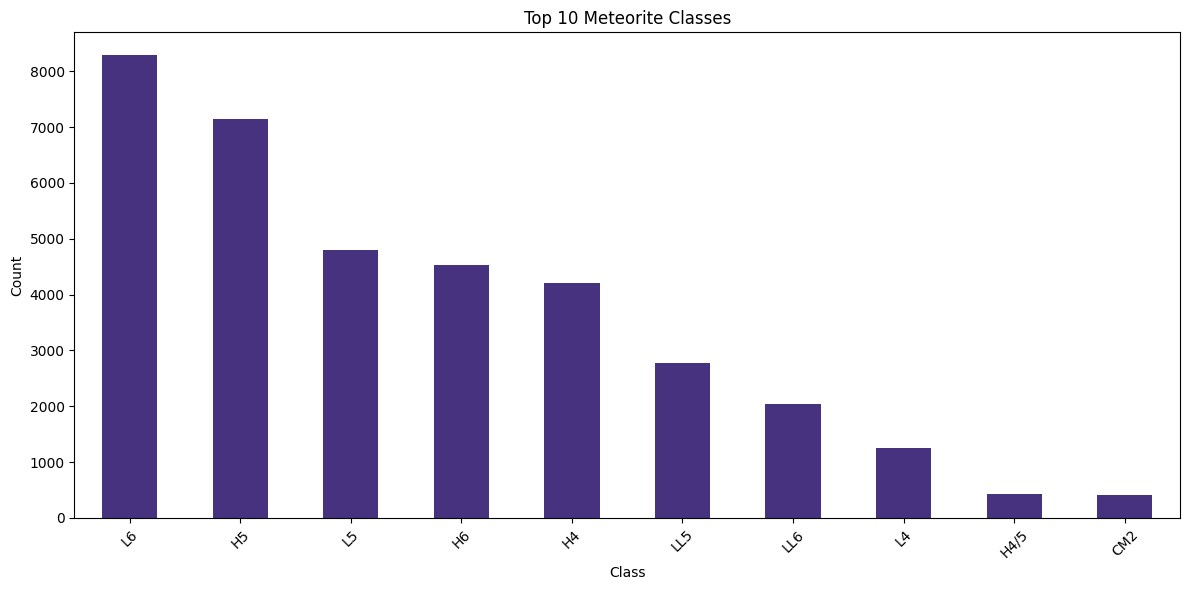

In [130]:
# distribution of mass classes
plt.figure(figsize=(12, 6))
df['recclass'].value_counts().head(10).plot(kind='bar')
plt.title('Top 10 Meteorite Classes')
plt.xlabel('Class')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('graphs/top_classes.png')
plt.show()

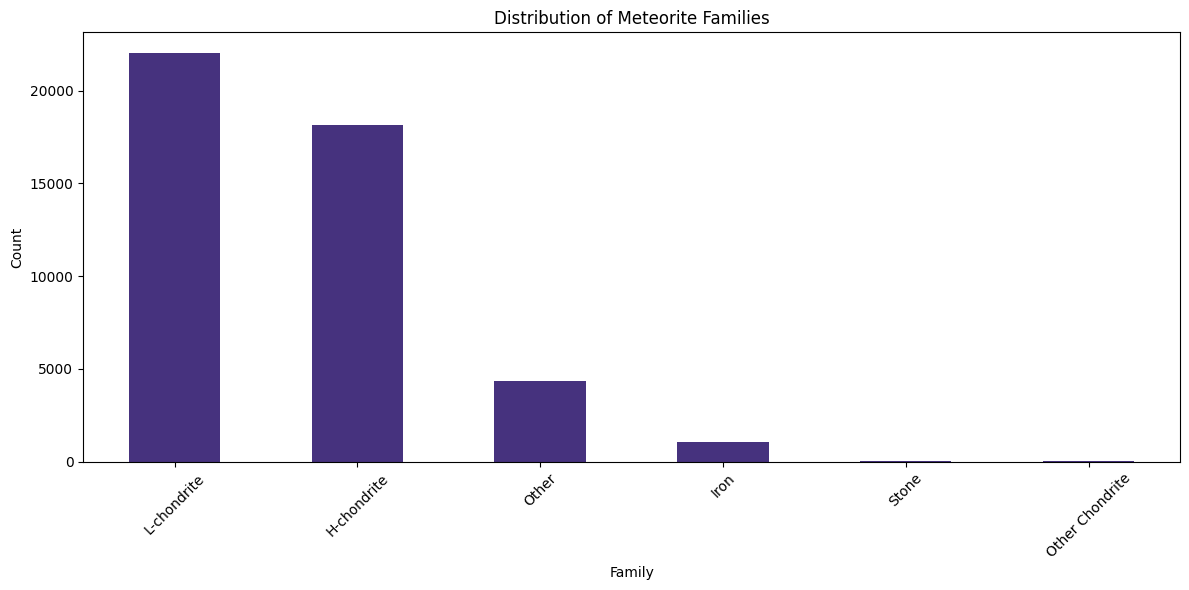

In [131]:
# meteorite family distribution
plt.figure(figsize=(12, 6))
df['meteorite_family'].value_counts().plot(kind='bar')
plt.title('Distribution of Meteorite Families')
plt.xlabel('Family')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('graphs/meteorite_families.png')
plt.show()

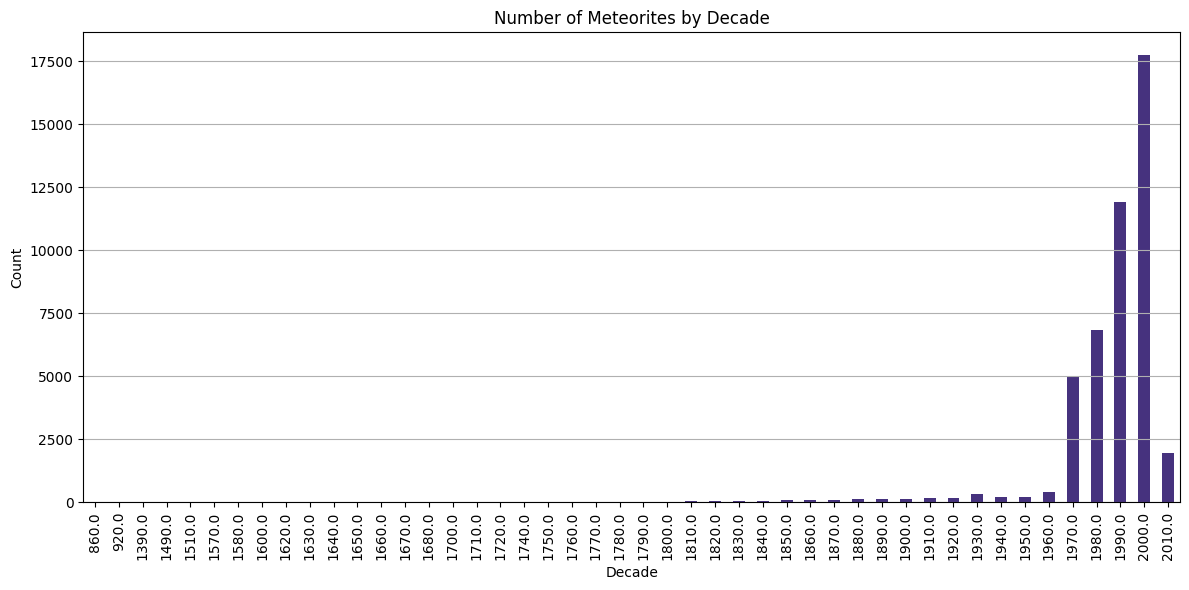

In [132]:
# temporal distribution
plt.figure(figsize=(12, 6))
decade_counts = df.groupby('decade').size()
decade_counts.plot(kind='bar')
plt.title('Number of Meteorites by Decade')
plt.xlabel('Decade')
plt.ylabel('Count')
plt.grid(axis='y')
plt.tight_layout()
plt.savefig('graphs/meteorites_by_decade.png')
plt.show()

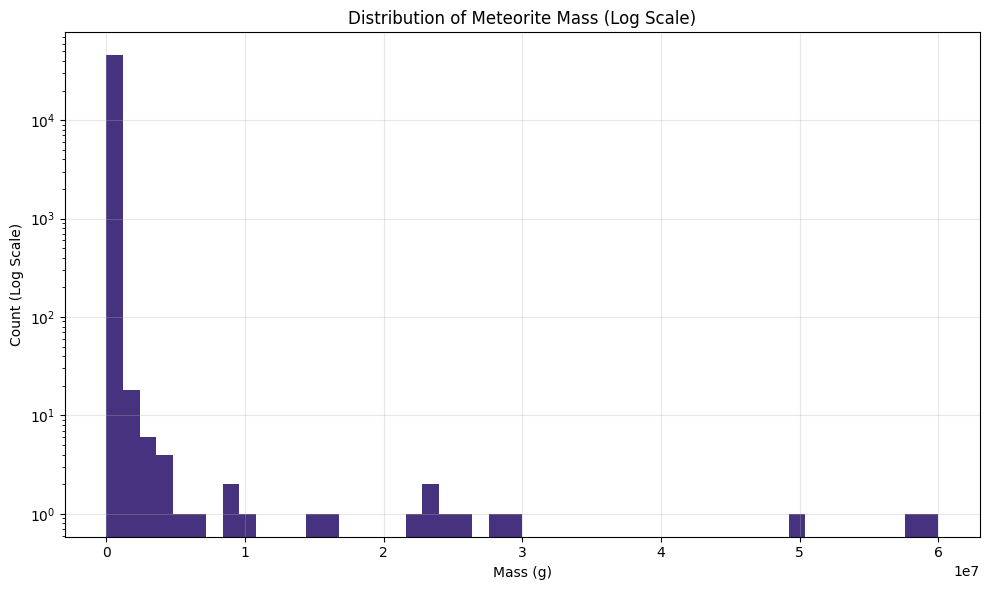

In [133]:
# mass distribution
plt.figure(figsize=(10, 6))
plt.hist(df['mass (g)'], bins=50, log=True)
plt.title('Distribution of Meteorite Mass (Log Scale)')
plt.xlabel('Mass (g)')
plt.ylabel('Count (Log Scale)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('graphs/mass_distribution.png')
plt.show()

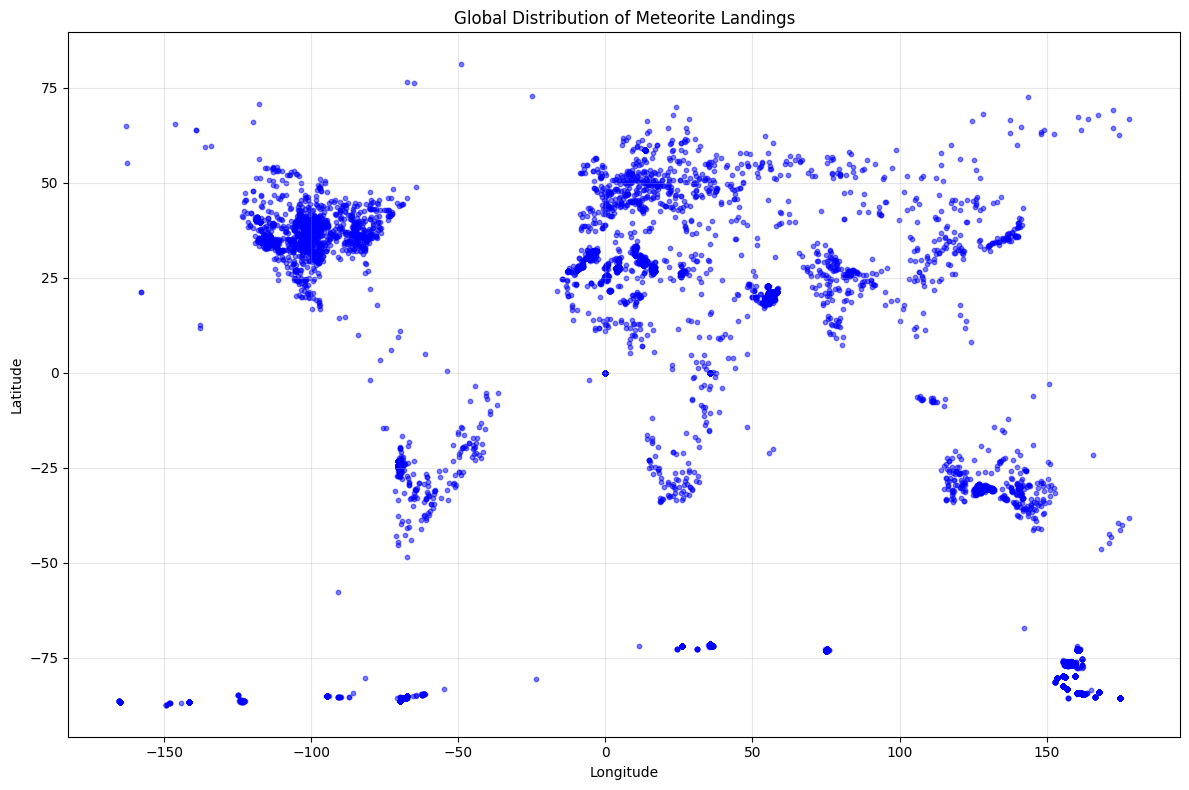

In [134]:
# geographical distribution
plt.figure(figsize=(12, 8))
plt.scatter(df['reclong'], df['reclat'], alpha=0.5, s=10, c='blue')
plt.title('Global Distribution of Meteorite Landings')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('graphs/meteorite_map.png')
plt.show()

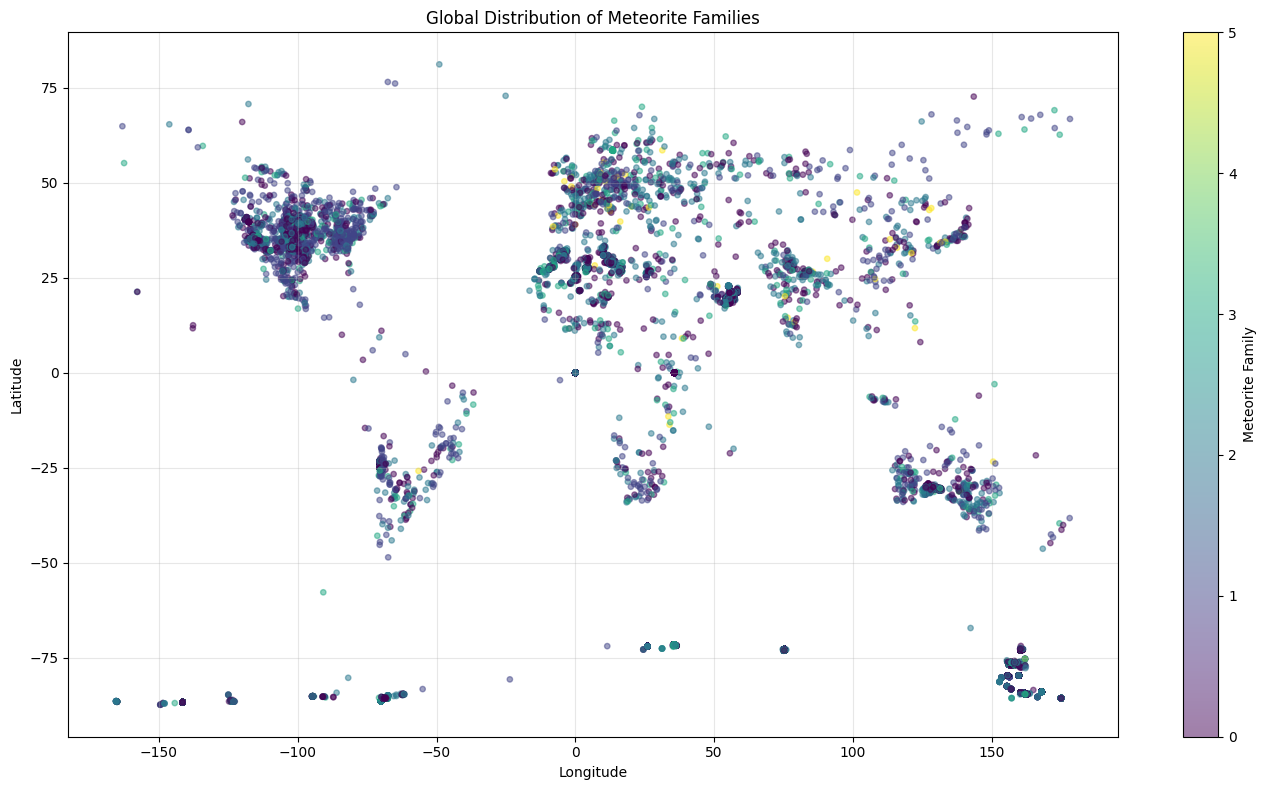

In [135]:
# distribuition by family
plt.figure(figsize=(14, 8))
geo_df = df.dropna(subset=['reclat', 'reclong'])
plt.scatter(geo_df['reclong'], geo_df['reclat'], 
            alpha=0.5, s=15, c=geo_df['meteorite_family'].astype('category').cat.codes, 
            cmap='viridis')
plt.title('Global Distribution of Meteorite Families')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.grid(True, alpha=0.3)
plt.colorbar(label='Meteorite Family')
plt.tight_layout()
plt.savefig('graphs/meteorite_family_map.png')
plt.show()

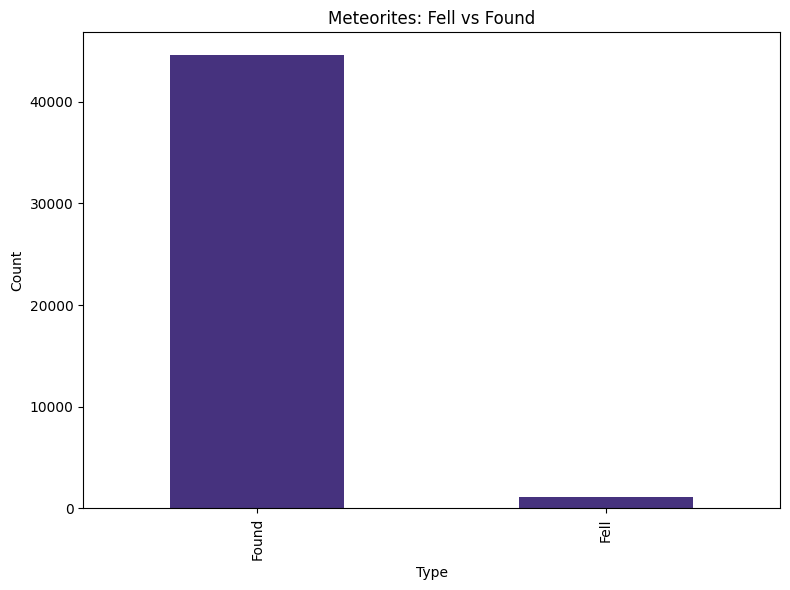

In [136]:
# fell vs found distribution
plt.figure(figsize=(8, 6))
df['fall'].value_counts().plot(kind='bar')
plt.title('Meteorites: Fell vs Found')
plt.xlabel('Type')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('graphs/fell_vs_found.png')
plt.show()

# Relationship Analysis
 
This section examines relationships between different variables to uncover patterns.

/Users/milton/anaconda3/envs/Statistics/lib/python3.12/site-packages/seaborn/categorical.py:640: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)


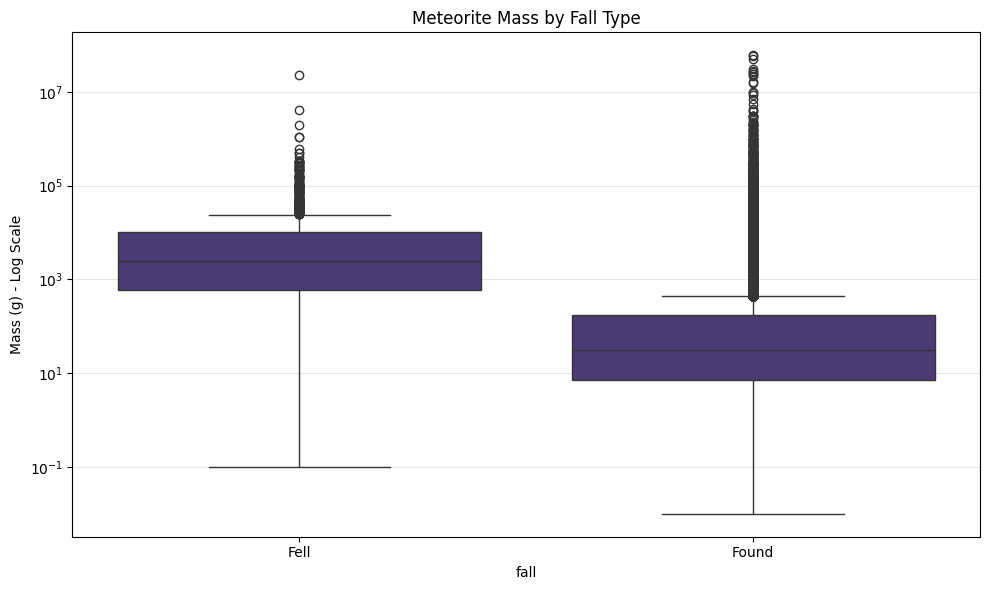

In [137]:
# mass vs fall type
plt.figure(figsize=(10, 6))
sns.boxplot(x='fall', y='mass (g)', data=df)
plt.yscale('log')
plt.title('Meteorite Mass by Fall Type')
plt.ylabel('Mass (g) - Log Scale')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('graphs/mass_by_fall.png')
plt.show()

/Users/milton/anaconda3/envs/Statistics/lib/python3.12/site-packages/seaborn/categorical.py:640: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)


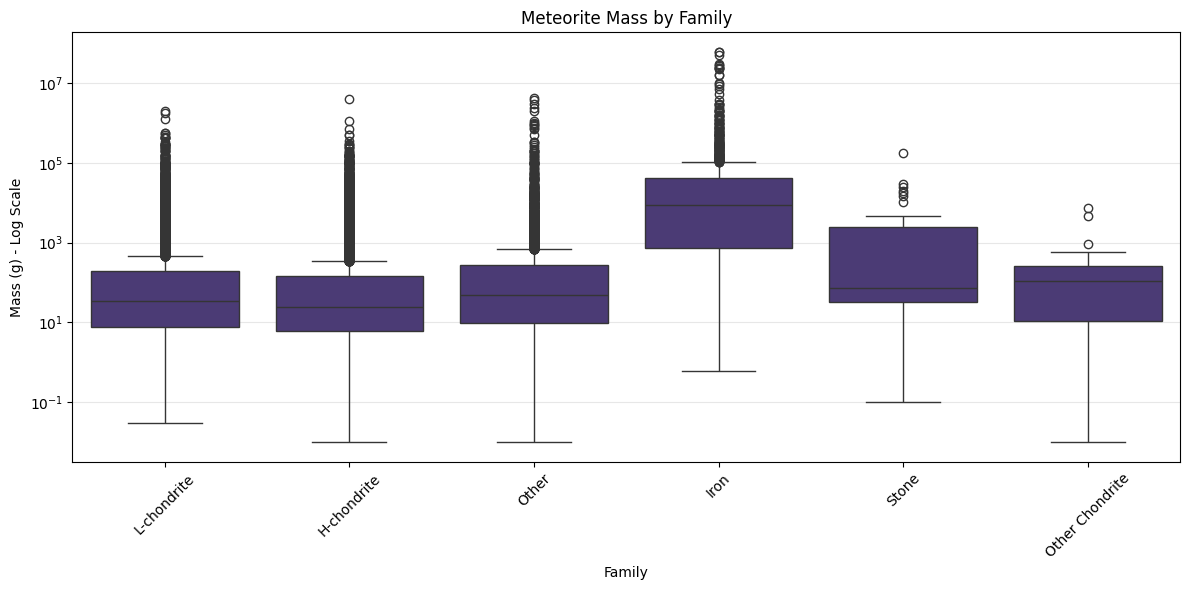

In [138]:
# mass vs meteorite family
plt.figure(figsize=(12, 6))
sns.boxplot(x='meteorite_family', y='mass (g)', data=df)
plt.yscale('log')
plt.title('Meteorite Mass by Family')
plt.xlabel('Family')
plt.ylabel('Mass (g) - Log Scale')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('graphs/mass_by_family.png')
plt.show()

/Users/milton/anaconda3/envs/Statistics/lib/python3.12/site-packages/seaborn/categorical.py:640: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)


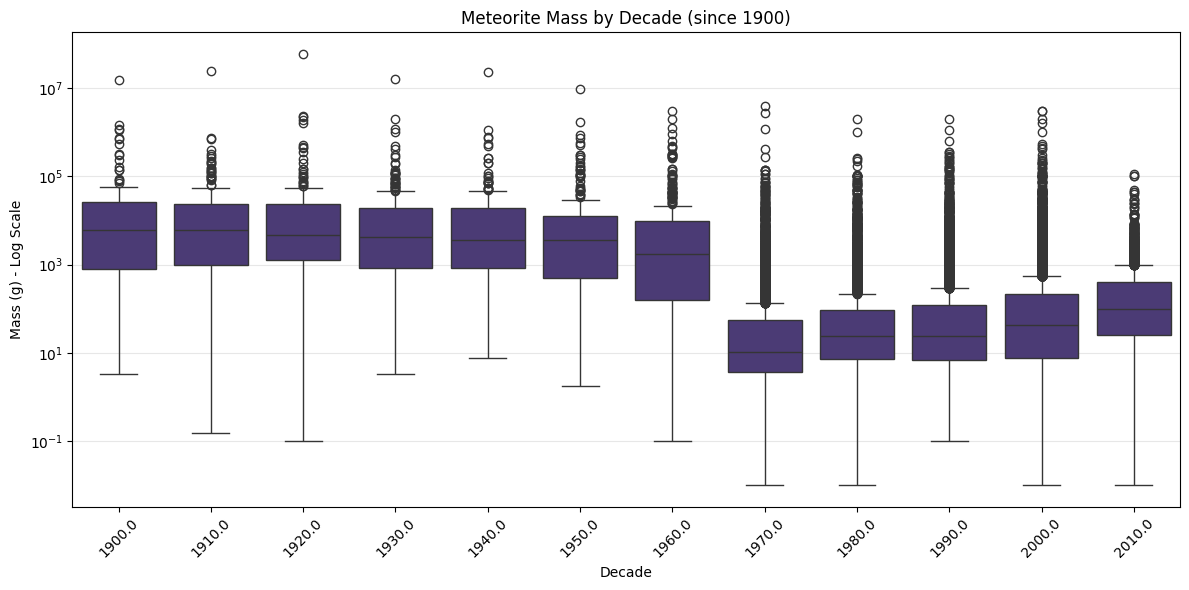

In [139]:
# mass vs decade 
plt.figure(figsize=(12, 6))
recent_df = df[df['decade'] >= 1900]  # Focus on more recent decades
sns.boxplot(x='decade', y='mass (g)', data=recent_df)
plt.yscale('log')
plt.title('Meteorite Mass by Decade (since 1900)')
plt.xlabel('Decade')
plt.ylabel('Mass (g) - Log Scale')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('graphs/mass_by_decade.png')
plt.show()

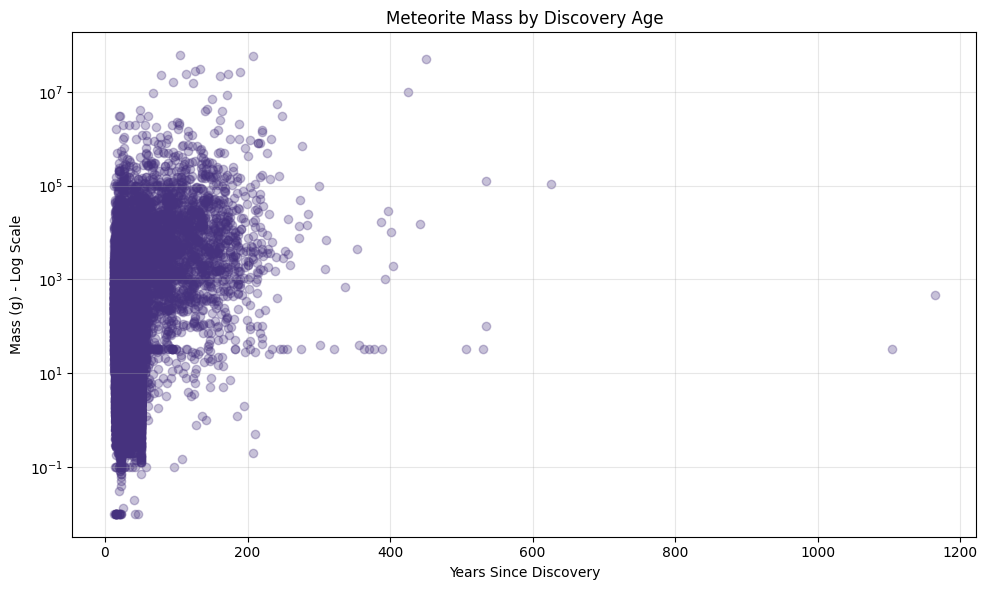

In [140]:
# mass vs discovery age
plt.figure(figsize=(10, 6))
plt.scatter(df['discovery_age'], df['mass (g)'], alpha=0.3)
plt.yscale('log')
plt.title('Meteorite Mass by Discovery Age')
plt.xlabel('Years Since Discovery')
plt.ylabel('Mass (g) - Log Scale')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('graphs/mass_by_age.png')
plt.show()

# Statistical Analysis 
This section applies statistical tests to validate observations and relationships identified in the exploratory analysis.

In [141]:
# t-test for mass comparison between fell and found meteorites
fell_masses = df[df['fall'] == 'Fell']['mass (g)']
found_masses = df[df['fall'] == 'Found']['mass (g)']

t_stat, p_value = stats.ttest_ind(fell_masses, found_masses, equal_var=False)
print(f"\nT-test comparing mass of fell vs. found meteorites:")
print(f"t-statistic: {t_stat:.4f}, p-value: {p_value:.4f}")
print(f"Result: {'Significant difference' if p_value < 0.05 else 'No significant difference'} in mass between fell and found meteorites")


T-test comparing mass of fell vs. found meteorites:
t-statistic: 1.5542, p-value: 0.1204
Result: No significant difference in mass between fell and found meteorites


In [142]:
# anova test for mass comparison across meteorite families
families = df['meteorite_family'].unique()
family_masses = [df[df['meteorite_family'] == family]['mass (g)'] for family in families]

f_stat, p_value = f_oneway(*family_masses)
print(f"\nANOVA test comparing mass across meteorite families:")
print(f"F-statistic: {f_stat:.4f}, p-value: {p_value:.4f}")
print(f"Result: {'Significant differences' if p_value < 0.05 else 'No significant differences'} in mass between meteorite families")


ANOVA test comparing mass across meteorite families:
F-statistic: 147.7638, p-value: 0.0000
Result: Significant differences in mass between meteorite families


In [143]:
# post-hoc tukey's HSD test since ANOVA indicated significant differences
# create a df for the post-hoc test
posthoc_data = pd.DataFrame({
    'mass': df['mass (g)'],
    'family': df['meteorite_family']
})

# perform Tukey's HSD test
tukey_result = pairwise_tukeyhsd(
    posthoc_data['mass'], 
    posthoc_data['family'],
    alpha=0.05
)

# display results
print("\nTukey's HSD Post-hoc Test Results:")
print(tukey_result)



Tukey's HSD Post-hoc Test Results:
                Multiple Comparison of Means - Tukey HSD, FWER=0.05                 
     group1          group2       meandiff   p-adj     lower        upper     reject
------------------------------------------------------------------------------------
    H-chondrite            Iron  479379.1122    0.0  428312.5158  530445.7086   True
    H-chondrite     L-chondrite     -16.4213    1.0  -16284.3792   16251.5366  False
    H-chondrite           Other    5582.5085 0.9922  -21761.2953   32926.3123  False
    H-chondrite Other Chondrite    -701.1804    1.0 -373305.0441  371902.6833  False
    H-chondrite           Stone    4847.7581    1.0 -222777.7713  232473.2874  False
           Iron     L-chondrite -479395.5336    0.0  -530211.244 -428579.8231   True
           Iron           Other -473796.6037    0.0 -529161.5167 -418431.6908   True
           Iron Other Chondrite -480080.2926 0.0037 -855781.2764 -104379.3088   True
           Iron           Sto

In [144]:
# create a more readable summary of the results
result_df = pd.DataFrame(data=tukey_result._results_table.data[1:], 
                        columns=tukey_result._results_table.data[0])


In [145]:
# display only significant differences
significant_pairs = result_df[result_df['p-adj'] < 0.05]
print("Significant mass differences between meteorite families:")
print(significant_pairs)

Significant mass differences between meteorite families:
        group1           group2     meandiff   p-adj        lower  \
0  H-chondrite             Iron  479379.1122  0.0000  428312.5158   
5         Iron      L-chondrite -479395.5336  0.0000 -530211.2440   
6         Iron            Other -473796.6037  0.0000 -529161.5167   
7         Iron  Other Chondrite -480080.2926  0.0037 -855781.2764   
8         Iron            Stone -474531.3542  0.0000 -707191.9903   

         upper  reject  
0  530445.7086    True  
5 -428579.8231    True  
6 -418431.6908    True  
7 -104379.3088    True  
8 -241870.7181    True  


In [146]:
# count how many significant differences each family has
families = df['meteorite_family'].unique()
print("Number of significant differences per family:")
for family in families:
    count = len(significant_pairs[(significant_pairs['group1'] == family) | 
                                (significant_pairs['group2'] == family)])
    print(f"- {family}: {count} significant differences")

Number of significant differences per family:
- L-chondrite: 1 significant differences
- H-chondrite: 1 significant differences
- Other: 1 significant differences
- Iron: 5 significant differences
- Stone: 1 significant differences
- Other Chondrite: 1 significant differences


# Cluster Analysis

This section identifies natural groupings in the meteorite data using unsupervised machine learning techniques.

In [147]:
# prep data for clustering
# Select features for clustering
features = ['log_mass', 'year', 'reclat', 'reclong']

In [148]:
# Create a dataframe with just the clustering features and family information
# Drop rows with missing values for any of these features
cluster_df = df[features + ['meteorite_family']].dropna()

In [149]:
print(f"Number of meteorites for clustering: {len(cluster_df)}")
print(f"Percentage with complete data: {len(cluster_df)/len(df):.1%}")

Number of meteorites for clustering: 38401
Percentage with complete data: 84.0%


In [150]:
# Examine distribution of families in clustering dataset
print("Meteorite family distribution in clustering dataset:")
print(cluster_df['meteorite_family'].value_counts())
print(f"\nIron meteorites: {(cluster_df['meteorite_family'] == 'Iron').sum()} ({(cluster_df['meteorite_family'] == 'Iron').sum()/len(cluster_df):.1%})")

Meteorite family distribution in clustering dataset:
meteorite_family
L-chondrite        17971
H-chondrite        16025
Other               3331
Iron                1014
Stone                 49
Other Chondrite       11
Name: count, dtype: int64

Iron meteorites: 1014 (2.6%)


In [151]:
# Normalise the data (this is important for k-means!)
scaler = StandardScaler()
scaled_features = scaler.fit_transform(cluster_df[features])

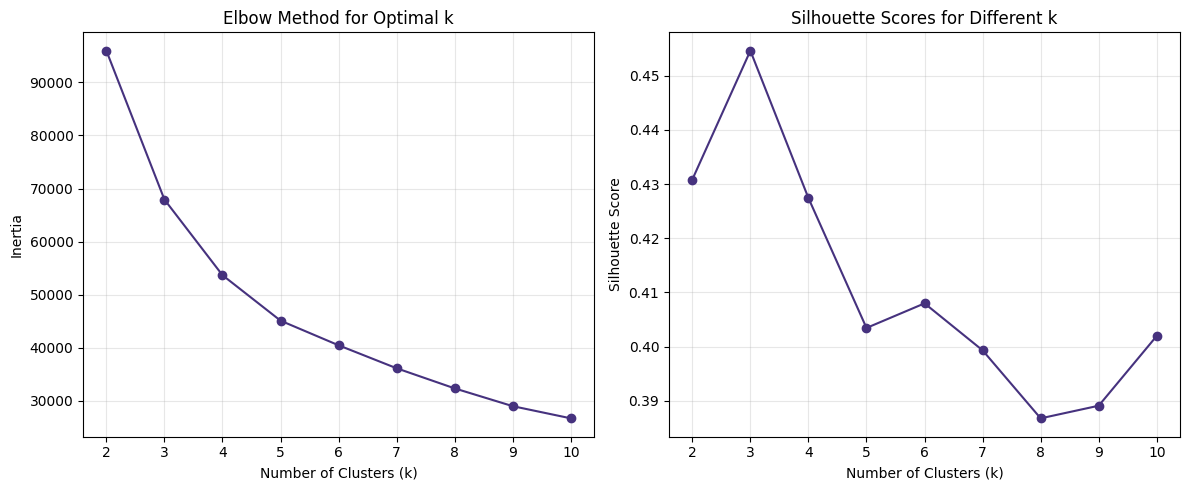

In [152]:
# determine optimal number of clusters using elbow method and silhouette score
inertia = []
silhouette_scores = []
k_range = range(2, 11)  # Try 2 to 10 clusters

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(scaled_features)
    inertia.append(kmeans.inertia_)
    
    # calculate silhouette score
    silhouette_scores.append(silhouette_score(scaled_features, cluster_labels))

# plot elbow method results
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(k_range, inertia, 'o-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal k')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(k_range, silhouette_scores, 'o-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Scores for Different k')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('graphs/optimal_clusters.png')
plt.show()

In [153]:
# based on the silhouette score plot, k=3 appears optimal
optimal_k = 3

# apply K-means with the optimal k
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(scaled_features)

# add cluster labels to the dataframe
cluster_df['cluster'] = cluster_labels

# get cluster centers and transform back to original scale
cluster_centers = kmeans.cluster_centers_
cluster_centers_original = scaler.inverse_transform(cluster_centers)

# convert log_mass back to original scale
cluster_centers_df = pd.DataFrame(cluster_centers_original, columns=features)
cluster_centers_df['mass (g)'] = np.expm1(cluster_centers_df['log_mass'])
cluster_centers_df = cluster_centers_df.drop('log_mass', axis=1)

print("Cluster Centers (in original scale):")
print(cluster_centers_df)

Cluster Centers (in original scale):
          year     reclat     reclong     mass (g)
0  2000.711259   6.398888    2.051905   108.883807
1  1990.150407 -75.981406  108.256219    16.181213
2  1902.665270  28.039777  -19.270361  6252.872456


In [154]:
# analyse clusters
print("Cluster Summary:")
for i in range(optimal_k):
    cluster_i = cluster_df[cluster_df['cluster'] == i]
    
    # calculate mass statistics from log_mass (converting back to original scale)
    avg_mass = np.expm1(cluster_i['log_mass'].mean())
    median_mass = np.expm1(cluster_i['log_mass'].median())
    
    print(f"\nCluster {i} characteristics:")
    print(f"  Size: {len(cluster_i)} meteorites ({len(cluster_i)/len(cluster_df):.1%} of total)")
    print(f"  Average mass: {avg_mass:.2f}g (log-transformed: {cluster_i['log_mass'].mean():.2f})")
    print(f"  Median mass: {median_mass:.2f}g")
    print(f"  Average year: {cluster_i['year'].mean():.2f}")
    print(f"  Geographic center: Lat {cluster_i['reclat'].mean():.2f}, Long {cluster_i['reclong'].mean():.2f}")
    
    # calculate percentage of iron meteorites in cluster
    iron_count = (cluster_i['meteorite_family'] == 'Iron').sum()
    iron_percent = iron_count / len(cluster_i) * 100 if len(cluster_i) > 0 else 0
    print(f"  Iron meteorites: {iron_count} ({iron_percent:.1f}%)")
    
    # most common family in cluster
    most_common = cluster_i['meteorite_family'].value_counts().idxmax()
    most_common_pct = cluster_i['meteorite_family'].value_counts().max() / len(cluster_i) * 100
    print(f"  Most common family: {most_common} ({most_common_pct:.1f}%)")



Cluster Summary:

Cluster 0 characteristics:
  Size: 14772 meteorites (38.5% of total)
  Average mass: 108.90g (log-transformed: 4.70)
  Median mass: 103.61g
  Average year: 2000.71
  Geographic center: Lat 6.39, Long 2.05
  Iron meteorites: 261 (1.8%)
  Most common family: L-chondrite (45.5%)

Cluster 1 characteristics:
  Size: 21720 meteorites (56.6% of total)
  Average mass: 16.18g (log-transformed: 2.84)
  Median mass: 12.77g
  Average year: 1990.15
  Geographic center: Lat -75.98, Long 108.26
  Iron meteorites: 131 (0.6%)
  Most common family: L-chondrite (49.3%)

Cluster 2 characteristics:
  Size: 1909 meteorites (5.0% of total)
  Average mass: 6252.87g (log-transformed: 8.74)
  Median mass: 6647.00g
  Average year: 1902.67
  Geographic center: Lat 28.04, Long -19.27
  Iron meteorites: 622 (32.6%)
  Most common family: Iron (32.6%)


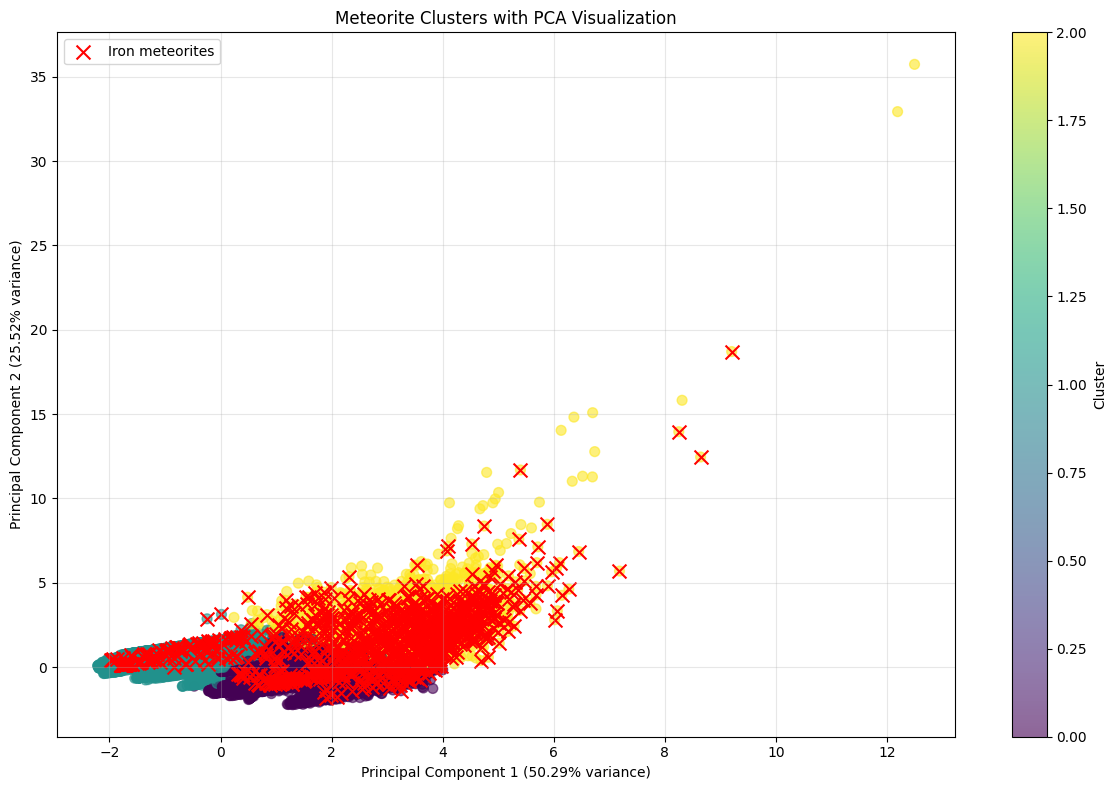

In [155]:
# visualise clusters using PCA
pca = PCA(n_components=2)
pca_result = pca.fit_transform(scaled_features)

# plot PCA results
plt.figure(figsize=(12, 8))
scatter = plt.scatter(pca_result[:, 0], pca_result[:, 1], 
                    c=cluster_labels, cmap='viridis', 
                    alpha=0.6, s=50)

# mark iron meteorites with a different shape
is_iron = cluster_df['meteorite_family'] == 'Iron'
plt.scatter(pca_result[is_iron, 0], pca_result[is_iron, 1], 
            c='red', marker='x', s=100, label='Iron meteorites')

plt.colorbar(scatter, label='Cluster')
plt.title('Meteorite Clusters with PCA Visualization')
plt.xlabel(f'Principal Component 1 ({pca.explained_variance_ratio_[0]:.2%} variance)')
plt.ylabel(f'Principal Component 2 ({pca.explained_variance_ratio_[1]:.2%} variance)')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig('graphs/meteorite_clusters_pca.png')
plt.show()

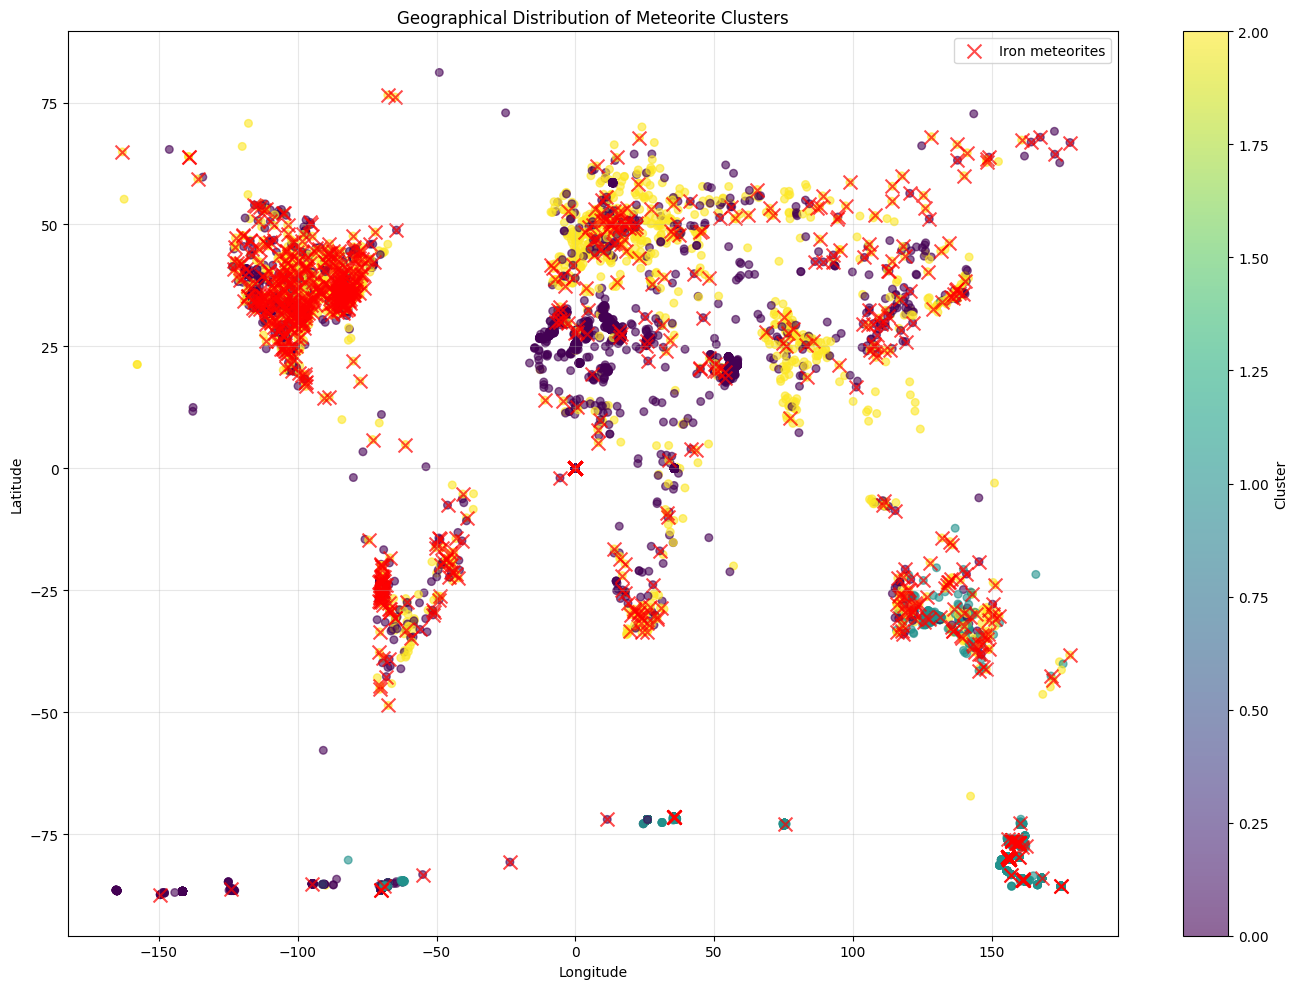

In [156]:
# visualise clusters on a map
plt.figure(figsize=(14, 10))
scatter = plt.scatter(cluster_df['reclong'], cluster_df['reclat'], 
                    c=cluster_df['cluster'], cmap='viridis', 
                    alpha=0.6, s=30)

# mark iron meteorites
plt.scatter(cluster_df.loc[is_iron, 'reclong'], cluster_df.loc[is_iron, 'reclat'],
            c='red', marker='x', s=100, alpha=0.7, label='Iron meteorites')

plt.colorbar(scatter, label='Cluster')
plt.title('Geographical Distribution of Meteorite Clusters')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig('graphs/meteorite_clusters_map.png')
plt.show()

/Users/milton/anaconda3/envs/Statistics/lib/python3.12/site-packages/seaborn/categorical.py:640: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)
/Users/milton/anaconda3/envs/Statistics/lib/python3.12/site-packages/seaborn/categorical.py:640: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)
/Users/milton/anaconda3/envs/Statistics/lib/python3.12/site-packages/seaborn/categorical.py:640: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)
/Users/milton/anaconda3/envs/Statistics/lib/python3.12/site-packages/seaborn/categorical.py:640: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positio

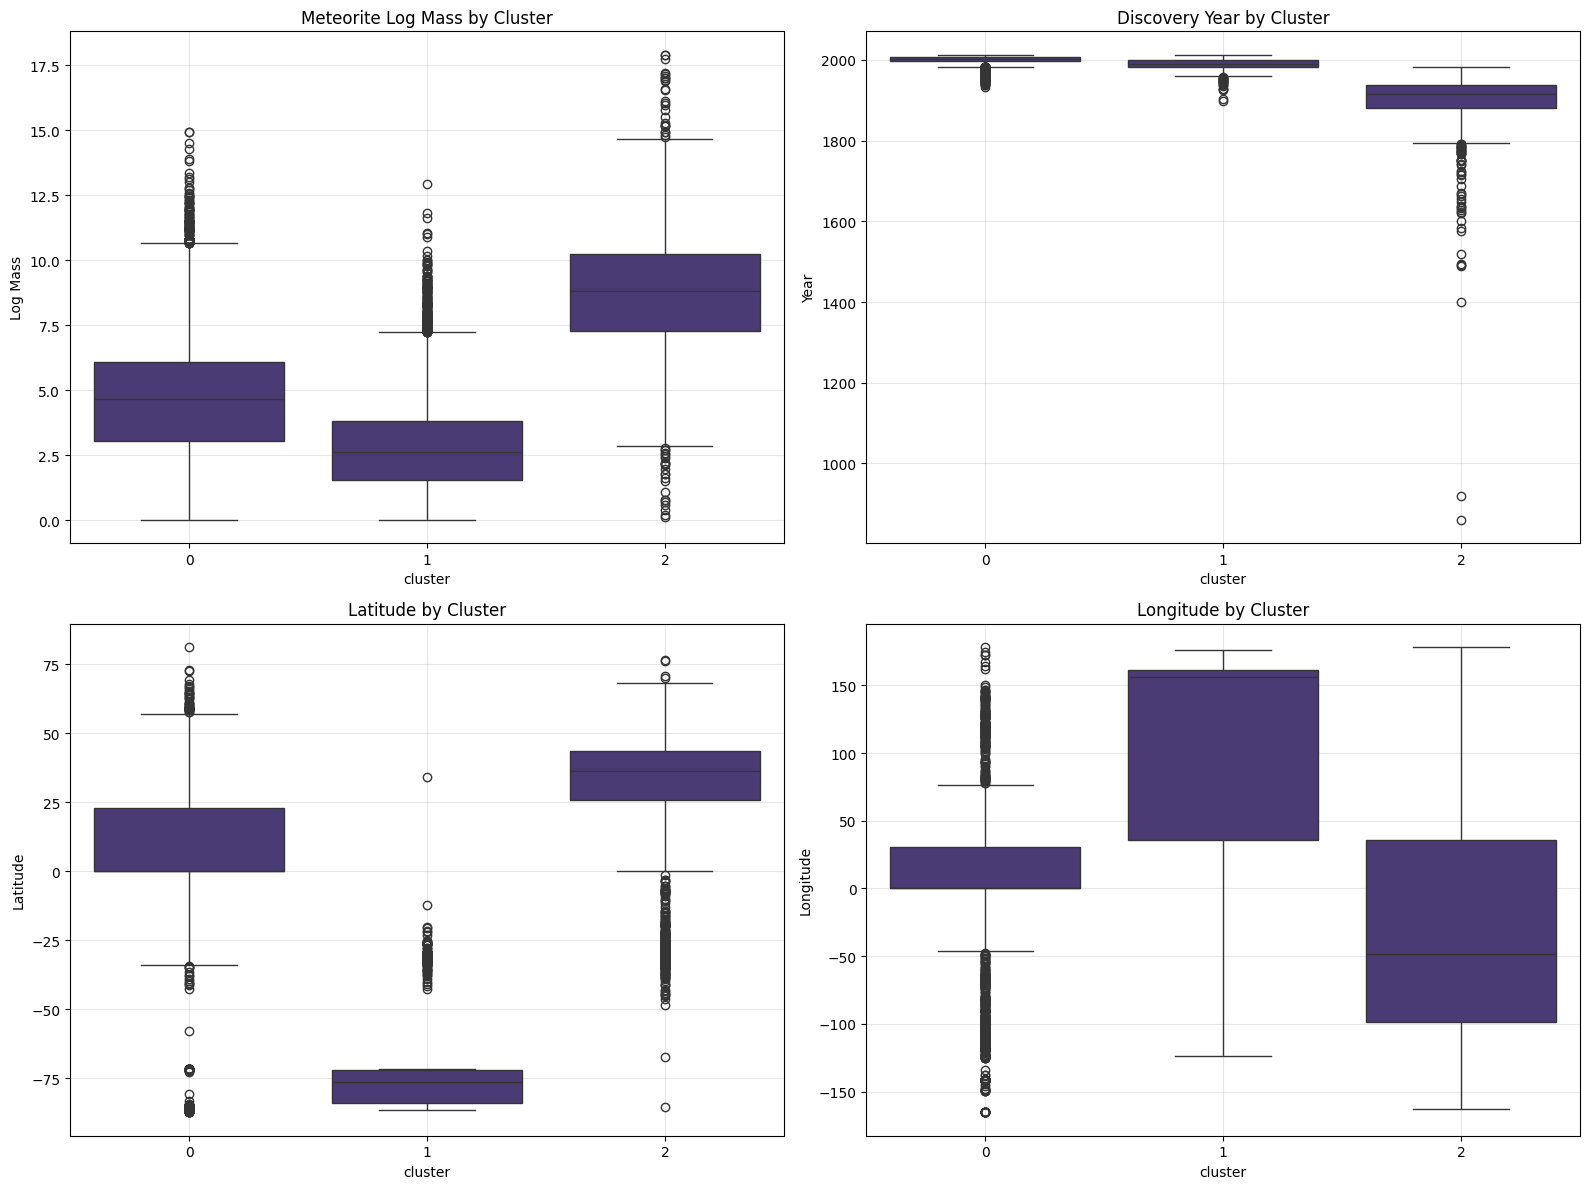

In [157]:
# visualise cluster feature distributions
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# mass distribution by cluster (log scale)
sns.boxplot(x='cluster', y='log_mass', data=cluster_df, ax=axes[0, 0])
axes[0, 0].set_title('Meteorite Log Mass by Cluster')
axes[0, 0].set_ylabel('Log Mass')
axes[0, 0].grid(True, alpha=0.3)

# year distribution by cluster
sns.boxplot(x='cluster', y='year', data=cluster_df, ax=axes[0, 1])
axes[0, 1].set_title('Discovery Year by Cluster')
axes[0, 1].set_ylabel('Year')
axes[0, 1].grid(True, alpha=0.3)

# latitude distribution by cluster
sns.boxplot(x='cluster', y='reclat', data=cluster_df, ax=axes[1, 0])
axes[1, 0].set_title('Latitude by Cluster')
axes[1, 0].set_ylabel('Latitude')
axes[1, 0].grid(True, alpha=0.3)

# longitude distribution by cluster
sns.boxplot(x='cluster', y='reclong', data=cluster_df, ax=axes[1, 1])
axes[1, 1].set_title('Longitude by Cluster')
axes[1, 1].set_ylabel('Longitude')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('graphs/cluster_feature_distributions.png')
plt.show()


# note to self: try fixing the FutureWarning (ok for now)

Meteorite Family Distribution within Clusters (%):
meteorite_family  H-chondrite       Iron  L-chondrite      Other  \
cluster                                                            
0                   41.280802   1.766856    45.450853  11.413485   
1                   43.397790   0.603131    49.267956   6.685083   
2                   26.244107  32.582504    29.125196  10.110005   

meteorite_family  Other Chondrite     Stone  
cluster                                      
0                        0.040617  0.047387  
1                        0.023020  0.023020  
2                        0.000000  1.938188  


<Figure size 1400x800 with 0 Axes>

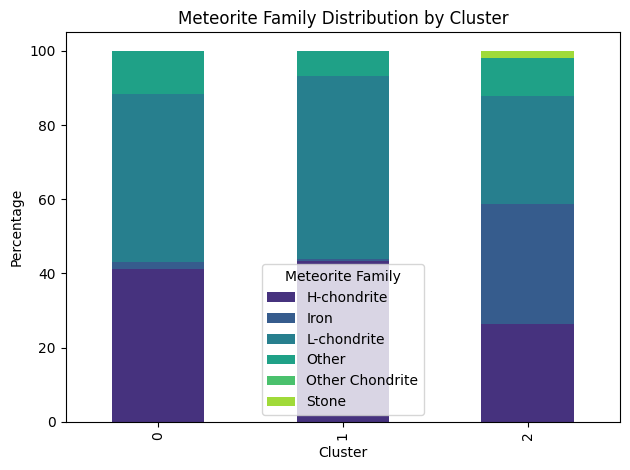

In [158]:
# analyse cluster vs family distribution
# create a crosstab of cluster vs family
cluster_family_cross = pd.crosstab(
    cluster_df['cluster'], 
    cluster_df['meteorite_family'], 
    normalize='index'
) * 100  # convert to percentages

print("Meteorite Family Distribution within Clusters (%):")
print(cluster_family_cross)

# visualise the distribution
plt.figure(figsize=(14, 8))
cluster_family_cross.plot(kind='bar', stacked=True)
plt.title('Meteorite Family Distribution by Cluster')
plt.xlabel('Cluster')
plt.ylabel('Percentage')
plt.legend(title='Meteorite Family')
plt.tight_layout()
plt.savefig('graphs/cluster_family_distribution.png')
plt.show()


In [159]:
# distribution of iron meteorites across clusters
iron_by_cluster = cluster_df[cluster_df['meteorite_family'] == 'Iron']['cluster'].value_counts(normalize=True) * 100
print("Distribution of iron meteorites across clusters:")
print(iron_by_cluster)

Distribution of iron meteorites across clusters:
cluster
2    61.341223
0    25.739645
1    12.919132
Name: proportion, dtype: float64


# Clustering with DBSCAN (Alternative Approach)

This section explores an alternative clustering method that can identify clusters of arbitrary shapes.


In [160]:
# apply dbscan clustering
print("DBSCAN Clustering")
dbscan = DBSCAN(eps=0.5, min_samples=5)
dbscan_labels = dbscan.fit_predict(scaled_features)

# count number of clusters (excluding noise points labeled as -1)
n_clusters = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise = list(dbscan_labels).count(-1)

print(f"Number of DBSCAN clusters: {n_clusters}")
print(f"Number of noise points: {n_noise} ({n_noise/len(cluster_df):.1%})")

# add DBSCAN labels to dataframe
cluster_df['dbscan_cluster'] = dbscan_labels

DBSCAN Clustering
Number of DBSCAN clusters: 15
Number of noise points: 417 (1.1%)


In [161]:
# compare K-means and DBSCAN clusters
if n_clusters > 0 and -1 not in dbscan_labels:
    # only calculate if DBSCAN found clusters and didn't label everything as noise
    agreement = (cluster_df['cluster'] == cluster_df['dbscan_cluster']).mean() * 100
    print(f"\nAgreement between K-means and DBSCAN: {agreement:.1f}%")

    # calculate Adjusted Rand Index to measure agreement
    ari = adjusted_rand_score(cluster_df['cluster'], cluster_df['dbscan_cluster'])
    print(f"Adjusted Rand Index: {ari:.4f}")

# Summary and Conclusions

 - Meteorite landings show clear patterns in geographical distribution, with concentrations in specific regions
 - Iron meteorites have significantly different mass characteristics compared to other meteorite families
 - Clustering reveals natural groupings based on mass, discovery year, and geographic location
 - The analysis suggests that human factors (collection methods, observation technology) play a significant role in meteorite discovery patterns